In [47]:
#command to run the notebook with all the variables and libraries needed for this notebook

%run /home/anomalocaris/LB2_project_group_9/SVM/SVM_benchmark.ipynb


[1/6] Loading /home/anomalocaris/LB2_project_group_9/SVM/subset1_arricchito.tsv
[2/6] Loading /home/anomalocaris/LB2_project_group_9/SVM/subset2_arricchito.tsv
[3/6] Loading /home/anomalocaris/LB2_project_group_9/SVM/subset3_arricchito.tsv
[4/6] Loading /home/anomalocaris/LB2_project_group_9/SVM/subset4_arricchito.tsv
[5/6] Loading /home/anomalocaris/LB2_project_group_9/SVM/subset5_arricchito.tsv
[6/6] Loading /home/anomalocaris/LB2_project_group_9/Data Preparation/benchmark_arricchito.tsv

Loaded 6 datasets
File 1: 1605 sequences
File 2: 1605 sequences
File 3: 1604 sequences
File 4: 1603 sequences
File 5: 1603 sequences
File 6: 2006 sequences

Split sizes:
  Train: 6415
  Val:   1605
  Test:  2006

Using 698 positive training sequences to train the PSWM

Detected 33 total features (indices 0..32).
Using 26 selected features.

Best SVM params on selected features: {'C': 10.0, 'gamma': 0.01}, Val MCC = 0.774

FINAL TEST MCC (benchmark, selected features) = 0.752


In [48]:
bench_seq_control=[] #lista che controlla ogni sequenza del benchmark se risulta TP,TF,FP,FN 

for i in range(len(y_test)):
    if y_test[i]==0 and y_pred_test[i]==0:
        bench_seq_control.append("TN")
    elif y_test[i]==1 and y_pred_test[i]==1:
        bench_seq_control.append("TP")
    elif y_test[i]==1 and y_pred_test[i]==0:
        bench_seq_control.append("FN")
    else: #if y_test[i]==0 and y_pred_test[i]==1:
        bench_seq_control.append("FP")

In [49]:
df=pd.read_csv("/home/anomalocaris/LB2_project_group_9/Data Preparation/benchmark_arricchito_with_target.tsv",sep="\t")

series_results_bench=pd.Series(bench_seq_control)

df["results"]=series_results_bench

In [50]:
df3=df.query('results=="FP" or results=="FN"')

df3.groupby("Kingdom").count()


,Accession,Organism,Sequence length,SP cleavage,transmembrane_term,Sequence,positive/negative,results
Kingdom,,,,,,,,
Discoba,1,1,1,1,1,1,1,1
Fungi,9,9,9,9,9,9,9,9
Metazoa,74,74,74,74,74,74,74,74
Sar,1,1,1,1,1,1,1,1
Viridiplantae,9,9,9,9,9,9,9,9


defaultdict(<class 'int'>, {'Metazoa': 74, 'Viridiplantae': 9, 'Fungi': 9, 'Sar': 1, 'Discoba': 1})


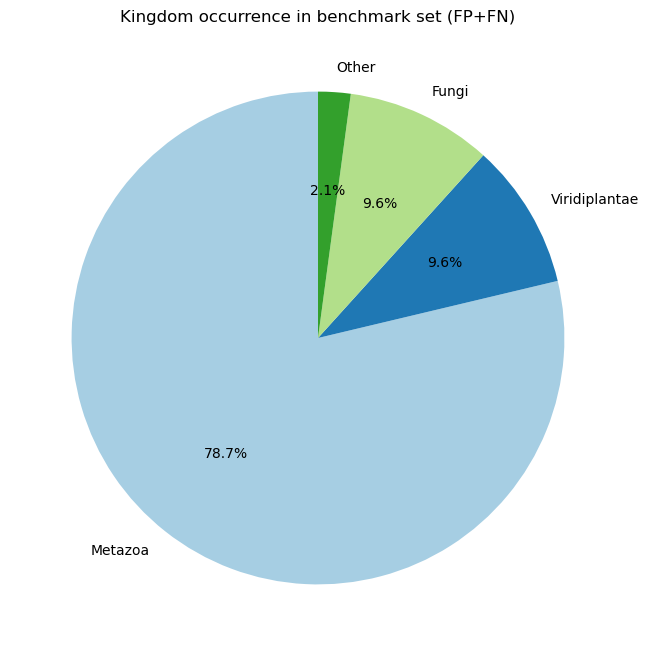

In [51]:
df_benchmark_kingdom=df3["Kingdom"].tolist()
total_entries_benchmark=len(df_benchmark_kingdom)
kingdoms_benchmark=defaultdict(int) #inizializza dizionario vuoto con valori uguali a zero, che poi sarà aggiornato durante il for loop

for element in df_benchmark_kingdom:
        kingdoms_benchmark[element]+=1
print(kingdoms_benchmark)
benchmark_pie = pd.DataFrame(kingdoms_benchmark.items(), columns=["Kingdom", "Occurrence"])

# Grouping the lesser represented taxa as "Other"
benchmark_pie = benchmark_pie.sort_values(by='Occurrence', ascending=False)
threshold = 5 # You can adjust this value

small_values = benchmark_pie[benchmark_pie['Occurrence'] < threshold]
main_values = benchmark_pie[benchmark_pie['Occurrence'] >= threshold]

# Create a new row for "Other"
other_occurrence = small_values['Occurrence'].sum()
other_row = pd.DataFrame([{'Kingdom': 'Other', 'Occurrence': other_occurrence}])

# Combine the data
cleaned_pie_data = pd.concat([main_values, other_row])

# Create the new pie chart
plt.figure(figsize=(8, 8))
plt.pie(cleaned_pie_data['Occurrence'], labels=cleaned_pie_data['Kingdom'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# Add title
plt.title('Kingdom occurrence in benchmark set (FP+FN)')
plt.savefig("Kingdom_occurrence_in_benchmark_set_pie.png",dpi=300, bbox_inches="tight")
plt.show()

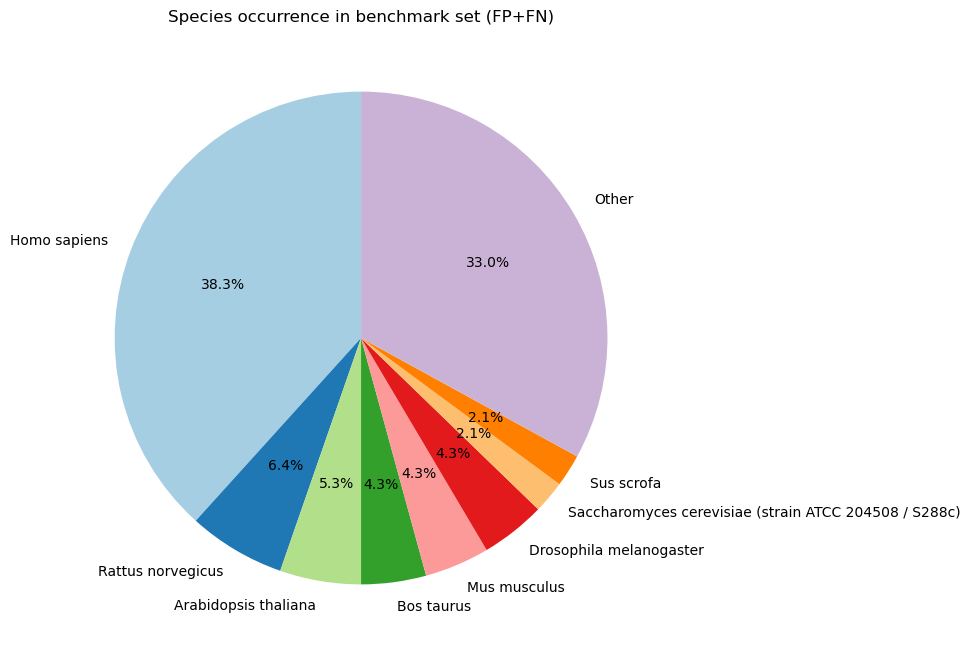

In [52]:
df_benchmark_organism=df3["Organism"].tolist()
total_entries_benchmark=len(df_benchmark_organism)
organism_benchmark=defaultdict(int) #inizializza dizionario vuoto con valori uguali a zero, che poi sarà aggiornato durante il for loop

for element in df_benchmark_organism:
        organism_benchmark[element]+=1

species_benchmark_pie = pd.DataFrame(organism_benchmark.items(), columns=["Organism", "Occurrence"])

# Grouping the lesser represented taxa as "Other"
species_benchmark_pie = species_benchmark_pie.sort_values(by='Occurrence', ascending=False)
threshold =  2 # You can adjust this value

small_values = species_benchmark_pie[species_benchmark_pie['Occurrence'] < threshold]
main_values = species_benchmark_pie[species_benchmark_pie['Occurrence'] >= threshold]

# Create a new row for "Other"
other_occurrence = small_values['Occurrence'].sum()
other_row = pd.DataFrame([{'Organism': 'Other', 'Occurrence': other_occurrence}])

# Combine the data
cleaned_pie_data = pd.concat([main_values, other_row])

# Create the new pie chart
plt.figure(figsize=(8, 8))
plt.pie(cleaned_pie_data['Occurrence'], labels=cleaned_pie_data['Organism'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# Add title
plt.title('Species occurrence in benchmark set (FP+FN)')
plt.savefig("Species_occurrence_in_benchmark_set_pie.png",dpi=300, bbox_inches="tight")
plt.show()


In [53]:
df3_fp=df3.query('results=="FP"')

In [54]:
df['transmembrane_term'].value_counts()

transmembrane_term
False    1654
Null      219
True      133
Name: count, dtype: int64

In [55]:
df3_fp['transmembrane_term'].value_counts()

transmembrane_term
True     20
False    19
Name: count, dtype: int64

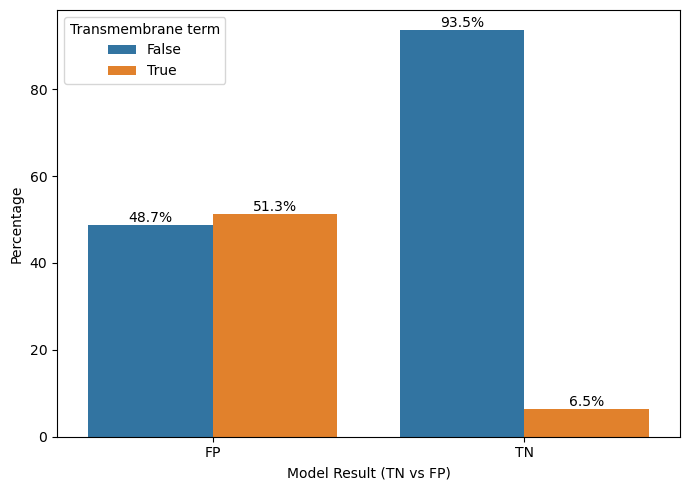

In [56]:
# Keep only the rows where the model result is TN or FP
df_sub = df[df["results"].isin(["TN", "FP"])]

# Exclude Null values in transmembrane_term ONLY for plotting
df_sub = df_sub[df_sub["transmembrane_term"].notna()]

# Count how many entries exist for each combination of (result, transmembrane_term)
counts = (
    df_sub
    .groupby(["results", "transmembrane_term"])
    .size()
    .rename("n")
    .reset_index()
)

# Compute percentages within each "results" group (TN or FP)
counts["percent"] = counts.groupby("results")["n"].transform(
    lambda s: (s / s.sum()) * 100
)

# Create the barplot
plt.figure(figsize=(7,5))
ax = sns.barplot(
    data=counts,
    x="results",              # TN and FP on the x-axis
    y="percent",              # percentage values
    hue="transmembrane_term"  # True vs False (no Null)
)

# Axis labels
ax.set_ylabel("Percentage")
ax.set_xlabel("Model Result (TN vs FP)")

# Legend title
ax.legend(title="Transmembrane term")

# Add percentage labels above each bar
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%")


plt.tight_layout()
plt.savefig(f"TN_vs_FP_results.png", dpi=300)
plt.show()

In [57]:
# lists for each group
logo_pos_seqs = []   # all true positives (class = Positive)
logo_neg_seqs = []   # all true negatives (class = Negative)
logo_fn_seqs  = []   # only FN
logo_fp_seqs  = []   # only FP

#  NEGATIVE CLASS (true label = Negative)

# all negatives: positive/negative == 0
logo_neg = df[df["positive/negative"] == 0]

# take N-terminal window [1:18] for all negatives
for _, row in logo_neg.iterrows():
    seq = row["Sequence"]
    subseq = seq[1:16]                  # same as your original code
    logo_neg_seqs.append(subseq)

    # subset: false positives (true negative but predicted positive)
    if row["results"] == "FP":
        logo_fp_seqs.append(subseq)

#POSITIVE CLASS (true label = Positive) 

# all positives: positive/negative == 1
logo_pos = df[df["positive/negative"] == 1]

for _, row in logo_pos.iterrows():
    seq = row["Sequence"]
    cleavage_position = int(row["SP cleavage"])      # position of SP cleavage
    subseq = seq[cleavage_position-13:cleavage_position+2]
    logo_pos_seqs.append(subseq)

    # subset: false negatives (true positive but predicted negative)
    if row["results"] == "FN":
        logo_fn_seqs.append(subseq)

# all four sequence sets collected here
logo_fullseqs = [logo_pos_seqs, logo_fn_seqs, logo_neg_seqs, logo_fp_seqs]


/home/anomalocaris/anaconda3/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'X' is not in color_dict. Using black.
  warnings.warn(str(Error))


<Figure size 1000x300 with 0 Axes>

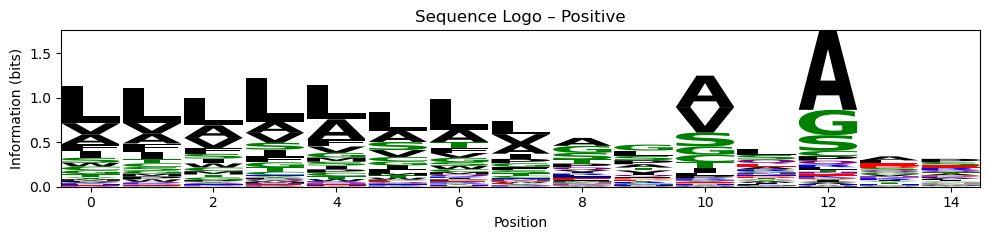

/home/anomalocaris/anaconda3/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'X' is not in color_dict. Using black.
  warnings.warn(str(Error))


<Figure size 1000x300 with 0 Axes>

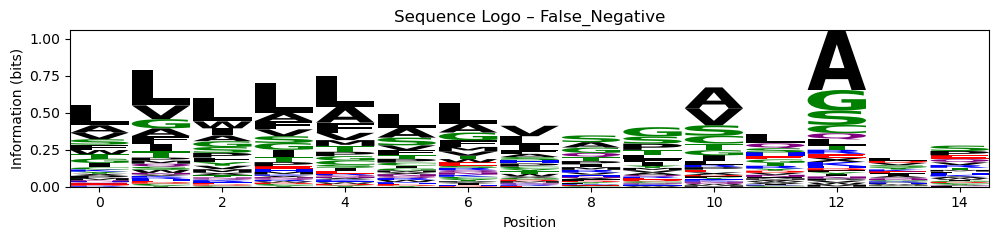

<Figure size 1000x300 with 0 Axes>

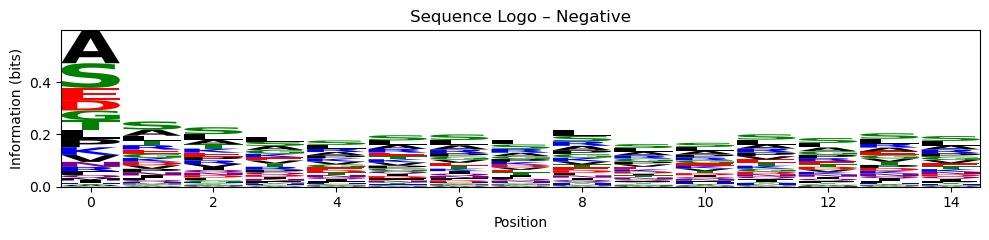

<Figure size 1000x300 with 0 Axes>

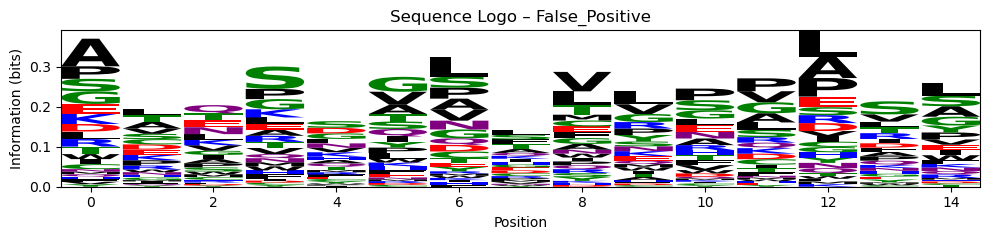

In [58]:
# Dictionary of all sets
logo_sets = {
    "Positive":       logo_pos_seqs,
    "False_Negative": logo_fn_seqs,
    "Negative":       logo_neg_seqs,
    "False_Positive": logo_fp_seqs,
}

for name, seqs in logo_sets.items():

    # Skip groups with no sequences
    if len(seqs) == 0:
        print(f"Skipping {name}: no sequences available.")
        continue

    # Convert alignment → information matrix
    mat = lm.alignment_to_matrix(sequences=seqs, to_type='information')

    # Create one figure per logo
    plt.figure(figsize=(10, 3))
    lm.Logo(mat, color_scheme="chemistry")
    plt.title(f"Sequence Logo – {name}")
    plt.xlabel("Position")
    plt.ylabel("Information (bits)")
    plt.tight_layout()
    plt.savefig(f"{name}_logo.png", dpi=300)
    plt.show()


In [59]:
files_training_SVM=["/home/anomalocaris/LB2_project_group_9/SVM/subset2_arricchito.tsv","/home/anomalocaris/LB2_project_group_9/SVM/subset3_arricchito.tsv","/home/anomalocaris/LB2_project_group_9/SVM/subset4_arricchito.tsv","/home/anomalocaris/LB2_project_group_9/SVM/subset5_arricchito.tsv"]
pos_train_seq=[]

for file in files_training_SVM:
    train_set=pd.read_csv(file,sep="\t")
    train_set['positive/negative'] = np.where(train_set['SP cleavage'] == 'False', 0, 1).astype(int)
    calamaro = train_set[train_set['positive/negative']==1]
    
    pos_seq=[]

    for _, row in calamaro.iterrows():
        sequence = row["Sequence"]
        cleavage = int(row["SP cleavage"])
        # estraggo la porzione di interesse
        pos_seq.append(sequence[cleavage-13:cleavage+2])
        
    pos_train_seq+=pos_seq

In [60]:
df_benchmark_tp=df.query('results=="TP"')
df_benchmark_fn=df.query('results=="FN"')

list_benchmark_tp=[]
list_benchmark_fn=[]

for _, row in df_benchmark_tp.iterrows():
        sequence = row["Sequence"]
        cleavage = int(row["SP cleavage"])
        # estraggo la porzione di interesse
        list_benchmark_tp.append(sequence[cleavage-13:cleavage+2])
for _, row in df_benchmark_fn.iterrows():
        sequence = row["Sequence"]
        cleavage = int(row["SP cleavage"])
        # estraggo la porzione di interesse
        list_benchmark_fn.append(sequence[cleavage-13:cleavage+2])

In [61]:
len(list_benchmark_tp)


164

In [62]:
len(list_benchmark_fn)

55

In [63]:
from collections import Counter

AMINOACIDS = ['A','C','D','E','F','G','H','I','K','L',
              'M','N','P','Q','R','S','T','V','W','Y']

def residue_freq(lista, AMINOACIDS):
  
    full_seq = "".join(lista)

    
    counts = Counter(full_seq)

    
    L = len(full_seq)

    freq = {f"{aa}": round((counts.get(aa, 0) / L),4)*100 for aa in AMINOACIDS}

    return freq


In [64]:
#computing the percentage of the important residues

def residue_freq_ALGV(lista):
    full_seq = "".join(lista)
    counts = Counter(full_seq)
    L = len(full_seq)

    target = ['A', 'L', 'G', 'V']
    freq_algv = {aa: round((counts.get(aa, 0) / L) * 100, 4) for aa in target}

    return freq_algv



In [65]:
diz_res_tp=residue_freq(list_benchmark_tp,AMINOACIDS)
diz_res_fn=residue_freq(list_benchmark_fn,AMINOACIDS)
diz_res_train=residue_freq(pos_train_seq,AMINOACIDS)

diz_res_tp_algv=residue_freq_ALGV(list_benchmark_tp)
diz_res_fn_algv=residue_freq_ALGV(list_benchmark_fn)
diz_res_train_algv=residue_freq_ALGV(pos_train_seq)

print(diz_res_tp_algv) #freq in benchmark tp of key aa residues
print(diz_res_fn_algv) #freq in benchmark fn of key aa residues
print(diz_res_train_algv) #freq in training of key aa residues

{'A': 18.0488, 'L': 22.439, 'G': 6.8293, 'V': 8.8618}
{'A': 12.8485, 'L': 20.9697, 'G': 7.6364, 'V': 8.3636}
{'A': 15.6734, 'L': 23.0659, 'G': 6.1987, 'V': 8.8348}


In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

benchmark_tp_plot = pd.DataFrame(diz_res_tp.items(), columns=["Residue", "Frequency (%)"])
benchmark_tp_plot['Dataset'] = 'benchmark_true_positive'
benchmark_fn_plot = pd.DataFrame(diz_res_fn.items(), columns=["Residue", "Frequency (%)"])
benchmark_fn_plot['Dataset'] = 'benchmark_false_negative'
training_pos = pd.DataFrame(diz_res_train.items(), columns=["Residue", "Frequency (%)"])
training_pos['Dataset'] = 'training_positive'

benchmark_tp_plot_algv = pd.DataFrame(diz_res_tp_algv.items(), columns=["Residue", "Frequency (%)"])
benchmark_tp_plot_algv['Dataset'] = 'benchmark_true_positive'
benchmark_fn_plot_algv = pd.DataFrame(diz_res_fn_algv.items(), columns=["Residue", "Frequency (%)"])
benchmark_fn_plot_algv['Dataset'] = 'benchmark_false_negative'
training_pos_algv = pd.DataFrame(diz_res_train_algv.items(), columns=["Residue", "Frequency (%)"])
training_pos_algv['Dataset'] = 'training_positive'

In [67]:
dataframe_comparison=pd.concat([benchmark_tp_plot,benchmark_fn_plot,training_pos], ignore_index=True)
dataframe_comparison_algv=pd.concat([benchmark_tp_plot_algv,benchmark_fn_plot_algv,training_pos_algv], ignore_index=True)

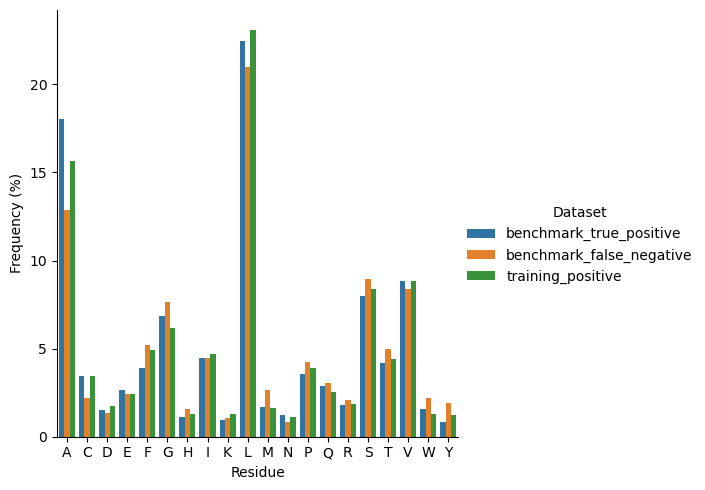

In [68]:
"""comparison delle composizioni """
sns.catplot(
    data=dataframe_comparison,
    x="Residue",
    y="Frequency (%)",
    hue="Dataset",  
    kind="bar"      
)

plt.savefig("residue_frequency_total_comparison.png", dpi=300, bbox_inches="tight")

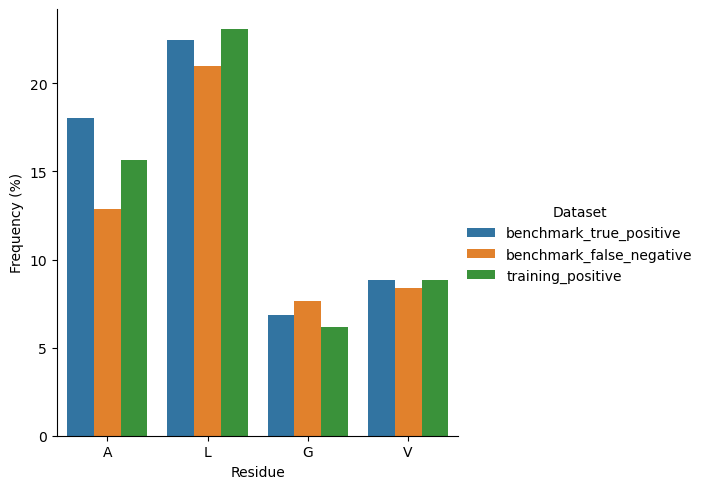

In [69]:
"""comparison delle composizioni """
sns.catplot(
    data=dataframe_comparison_algv,
    x="Residue",
    y="Frequency (%)",
    hue="Dataset",  
    kind="bar"      
)

plt.savefig("residue_frequency_total_comparison_algv.png", dpi=300, bbox_inches="tight")

In [70]:
files_training_SVM=["/home/anomalocaris/LB2_project_group_9/SVM/subset2_arricchito.tsv","/home/anomalocaris/LB2_project_group_9/SVM/subset3_arricchito.tsv","/home/anomalocaris/LB2_project_group_9/SVM/subset4_arricchito.tsv","/home/anomalocaris/LB2_project_group_9/SVM/subset5_arricchito.tsv"]

all_train_pos=pd.DataFrame()
for file in files_training_SVM:
    train_set=pd.read_csv(file,sep="\t")
    train_set['positive/negative'] = np.where(train_set['SP cleavage'] == 'False', 0, 1).astype(int)
    calamaro = train_set[train_set['positive/negative']==1]
    all_train_pos=pd.concat([all_train_pos,calamaro],ignore_index=True)

In [71]:
signal_peptide_length_comparison=pd.concat([df,all_train_pos],ignore_index=True)

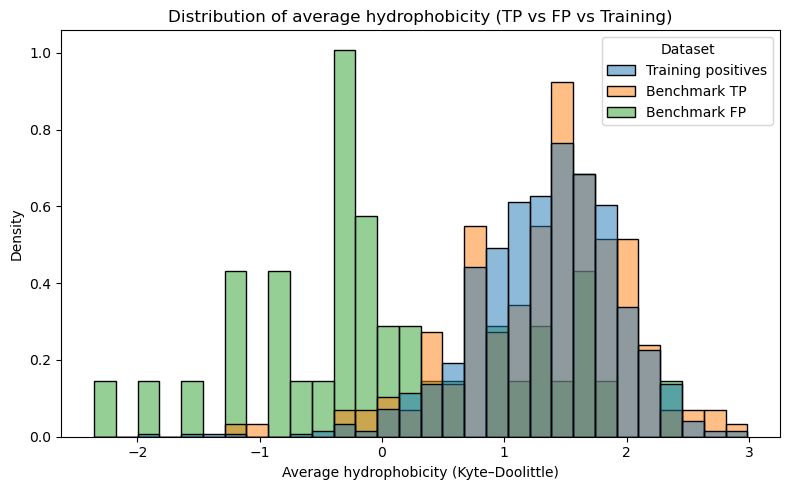

In [72]:
df_benchmark_fp = df.query('results=="FP"')

list_benchmark_fp = []
for _, row in df_benchmark_fp.iterrows():
    seq = row["Sequence"]
    sp_cleave = row["SP cleavage"]

    if sp_cleave != "False":
        
        cleavage = int(sp_cleave)
        window = seq[cleavage-13 : cleavage+2]
    else:
        
        window = seq[:15]   # oppure seq[1:16]

    list_benchmark_fp.append(window)
KD_SCALE = {
    'A': 1.8, 'C': 2.5, 'D': -3.5, 'E': -3.5, 'F': 2.8,
    'G': -0.4, 'H': -3.2, 'I': 4.5, 'K': -3.9, 'L': 3.8,
    'M': 1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5, 'R': -4.5,
    'S': -0.8, 'T': -0.7, 'V': 4.2, 'W': -0.9, 'Y': -1.3
}

def mean_hydrophobicity(seq):
    vals = [KD_SCALE.get(aa, 0) for aa in seq]
    return np.mean(vals)

hydro_train = [mean_hydrophobicity(s) for s in pos_train_seq]
hydro_tp    = [mean_hydrophobicity(s) for s in list_benchmark_tp]
hydro_fp    = [mean_hydrophobicity(s) for s in list_benchmark_fp]

df_hydro_fp = pd.DataFrame({
    "Hydrophobicity": hydro_train + hydro_tp + hydro_fp,
    "Dataset": (["Training positives"] * len(hydro_train) +
                ["Benchmark TP"]      * len(hydro_tp) +
                ["Benchmark FP"]      * len(hydro_fp))
})

plt.figure(figsize=(8,5))
sns.histplot(
    data=df_hydro_fp,
    x="Hydrophobicity",
    hue="Dataset",
    stat="density",
    common_norm=False,
    bins=30,
    multiple="layer",
    alpha=0.5
)
plt.title("Distribution of average hydrophobicity (TP vs FP vs Training)")
plt.xlabel("Average hydrophobicity (Kyte–Doolittle)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("hydrophobicity_TP_vs_FP_vs_training.png", dpi=300)
plt.show()

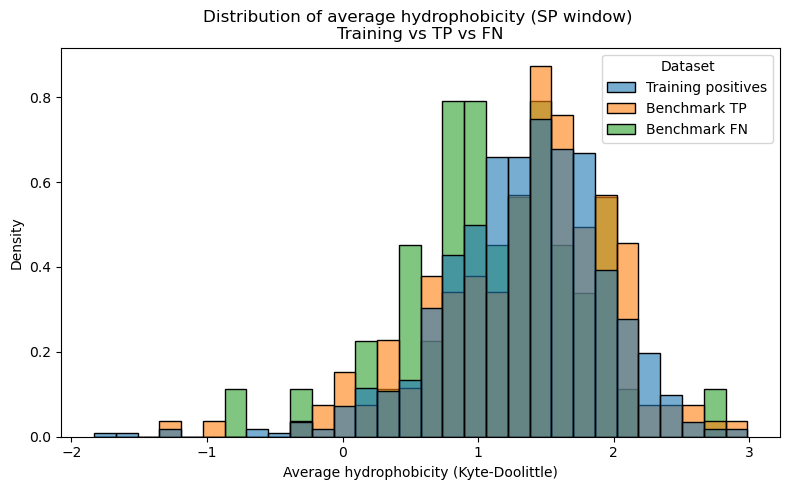

In [73]:
# Seleziono TP e FN dal dataframe principale
df_benchmark_tp = df.query('results=="TP"')
df_benchmark_fn = df.query('results=="FN"')

# Costruisco le finestre SP per TP
list_benchmark_tp = []
for _, row in df_benchmark_tp.iterrows():
    seq = row["Sequence"]
    sp_cleave = row["SP cleavage"]

    if sp_cleave != "False":
        # SP annotata → uso finestra centrata sulla zona di taglio
        cleavage = int(sp_cleave)
        window = seq[cleavage-13 : cleavage+2]   # 15 aa: -13 .. +1
    else:
        # fallback raro (nel TP dovrebbe quasi sempre esserci la SP)
        window = seq[:15]

    list_benchmark_tp.append(window)

# Costruisco le finestre SP per FN
list_benchmark_fn = []
for _, row in df_benchmark_fn.iterrows():
    seq = row["Sequence"]
    sp_cleave = row["SP cleavage"]

    if sp_cleave != "False":
        cleavage = int(sp_cleave)
        window = seq[cleavage-13 : cleavage+2]
    else:
        # teoricamente nei FN dovresti avere sempre una SP annotata,
        # ma per sicurezza metto lo stesso fallback
        window = seq[:15]

    list_benchmark_fn.append(window)


# Kyte-Doolittle hydrophobicity scale
KD_SCALE = {
    'A': 1.8,  'C': 2.5,  'D': -3.5, 'E': -3.5,
    'F': 2.8,  'G': -0.4, 'H': -3.2,'I': 4.5,
    'K': -3.9, 'L': 3.8,  'M': 1.9, 'N': -3.5,
    'P': -1.6, 'Q': -3.5, 'R': -4.5,'S': -0.8,
    'T': -0.7, 'V': 4.2,  'W': -0.9,'Y': -1.3
}

def mean_hydrophobicity(seq, scale=KD_SCALE):
    """
    Ritorna l'idrofobicità media della sequenza
    usando la scala fornita (di default Kyte-Doolittle).
    Ignora i residui non presenti nella scala (es. X, B, Z).
    """
    vals = [scale[aa] for aa in seq if aa in scale]
    if len(vals) == 0:
        return np.nan
    return np.mean(vals)

# idrofobicità media per ogni finestra di sequenza
# (pos_train_seq suppongo sia già una lista di finestre SP di training)
hydro_train = [mean_hydrophobicity(s) for s in pos_train_seq]
hydro_tp    = [mean_hydrophobicity(s) for s in list_benchmark_tp]
hydro_fn    = [mean_hydrophobicity(s) for s in list_benchmark_fn]

# Costruisco un unico DataFrame con una colonna 'Dataset'
df_hydro = pd.DataFrame({
    "Hydrophobicity": hydro_train + hydro_tp + hydro_fn,
    "Dataset": (["Training positives"] * len(hydro_train) +
                ["Benchmark TP"]      * len(hydro_tp) +
                ["Benchmark FN"]      * len(hydro_fn))
})

# Rimuovo eventuali NaN
df_hydro = df_hydro.dropna()

plt.figure(figsize=(8,5))
sns.histplot(
    multiple="layer",
    alpha=0.6,
    data=df_hydro,
    x="Hydrophobicity",
    hue="Dataset",
    #kde=True,
    stat="density",
    common_norm=False,
    bins=30
)

plt.title("Distribution of average hydrophobicity (SP window) \nTraining vs TP vs FN")
plt.xlabel("Average hydrophobicity (Kyte-Doolittle)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("hydrophobicity_distribution_all.png", dpi=300)
plt.show()


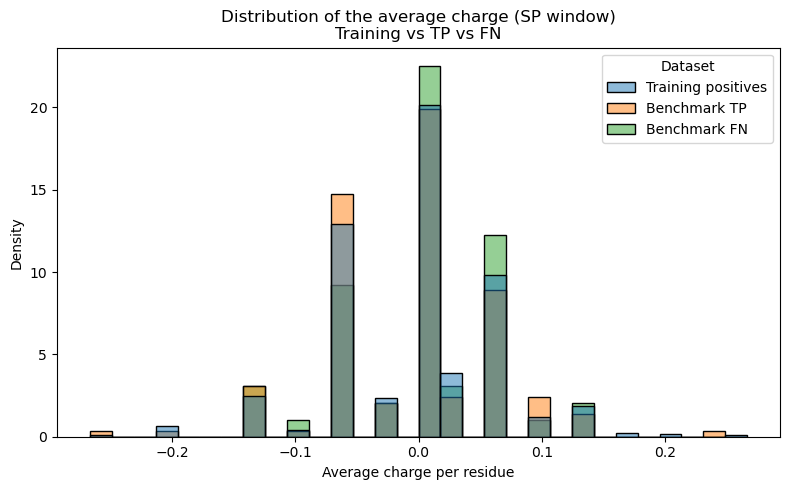

In [74]:
# Scala semplificata di carica a pH ~7
CHARGE_SCALE = {
    'D': -1.0,
    'E': -1.0,
    'K':  1.0,
    'R':  1.0,
    'H':  0.5,   # opzionale: parzialmente positiva
}

def mean_charge(seq, scale=CHARGE_SCALE):
    """
    Carica media per residuo nella sequenza.
    Considera solo D,E,K,R,H; gli altri aa hanno carica 0.
    """
    vals = [scale.get(aa, 0.0) for aa in seq]
    if len(vals) == 0:
        return np.nan
    return np.mean(vals)

# carica media per ogni finestra di sequenza
charge_train = [mean_charge(s) for s in pos_train_seq]
charge_tp    = [mean_charge(s) for s in list_benchmark_tp]
charge_fn    = [mean_charge(s) for s in list_benchmark_fn]

# Costruisco un unico DataFrame
df_charge = pd.DataFrame({
    "Charge": charge_train + charge_tp + charge_fn,
    "Dataset": (["Training positives"] * len(charge_train) +
                ["Benchmark TP"]      * len(charge_tp) +
                ["Benchmark FN"]      * len(charge_fn))
})

# Rimuovo eventuali NaN (in teoria non dovresti averne)
df_charge = df_charge.dropna()

plt.figure(figsize=(8,5))
sns.histplot(
    data=df_charge,
    x="Charge",
    hue="Dataset",
    multiple="layer",
    alpha=0.5,
    stat="density",
    common_norm=False,
    bins=30

)

plt.title("Distribution of the average charge (SP window)\nTraining vs TP vs FN")
plt.xlabel("Average charge per residue")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("charge_distribution_all.png", dpi=300, bbox_inches="tight")
plt.show()

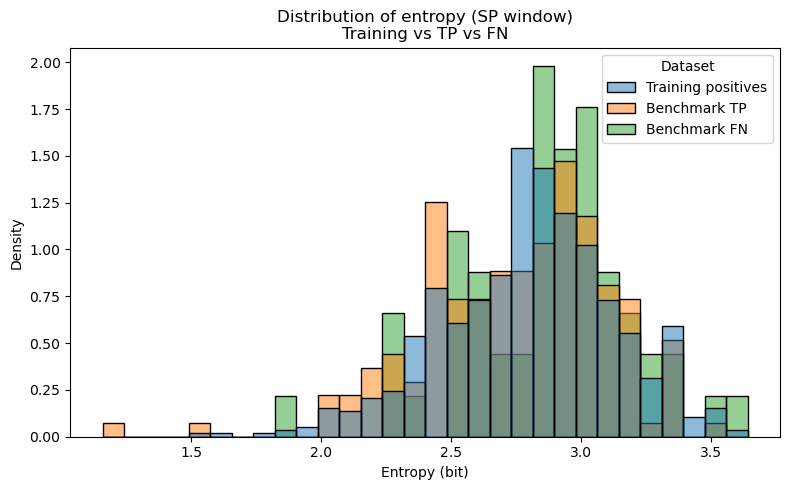

In [75]:
#ENTROPY PLOT
AMINOACIDS = ['A','C','D','E','F','G','H','I','K','L',
              'M','N','P','Q','R','S','T','V','W','Y']

def shannon_entropy(seq):
    seq = [aa for aa in seq if aa in AMINOACIDS]  
    if len(seq) == 0:
        return np.nan
    
    counts = Counter(seq)
    L = len(seq)
    probs = [counts[aa] / L for aa in counts]
    return -sum(p * np.log2(p) for p in probs)

entropy_train = [shannon_entropy(s) for s in pos_train_seq]
entropy_tp    = [shannon_entropy(s) for s in list_benchmark_tp]
entropy_fn    = [shannon_entropy(s) for s in list_benchmark_fn]

df_entropy = pd.DataFrame({
    "Entropy": entropy_train + entropy_tp + entropy_fn,
    "Dataset": (["Training positives"] * len(entropy_train) +
                ["Benchmark TP"]      * len(entropy_tp) +
                ["Benchmark FN"]      * len(entropy_fn))
})
df_entropy = df_entropy.dropna()

plt.figure(figsize=(8,5))
sns.histplot(
    data=df_entropy,
    x="Entropy",
    hue="Dataset",
    stat="density",
    common_norm=False,
    bins=30,
    multiple="layer",
    alpha=0.5
)

plt.title("Distribution of entropy (SP window)\nTraining vs TP vs FN")
plt.xlabel("Entropy (bit)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("entropy_distribution_TP_FN_training.png", dpi=300)
plt.show()

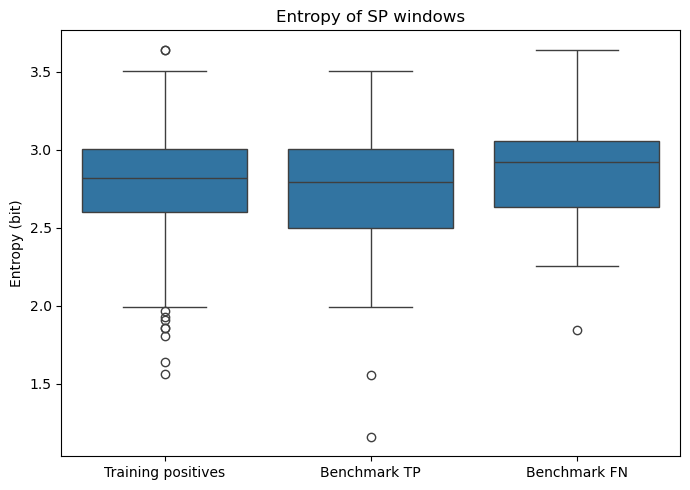

In [76]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df_entropy,
    x="Dataset",
    y="Entropy",
    order=["Training positives", "Benchmark TP", "Benchmark FN"]
)
plt.title("Entropy of SP windows")
plt.ylabel("Entropy (bit)")
plt.xlabel("")
plt.tight_layout()
plt.savefig("entropy_boxplot_TP_FN_training.png", dpi=300)
plt.show()

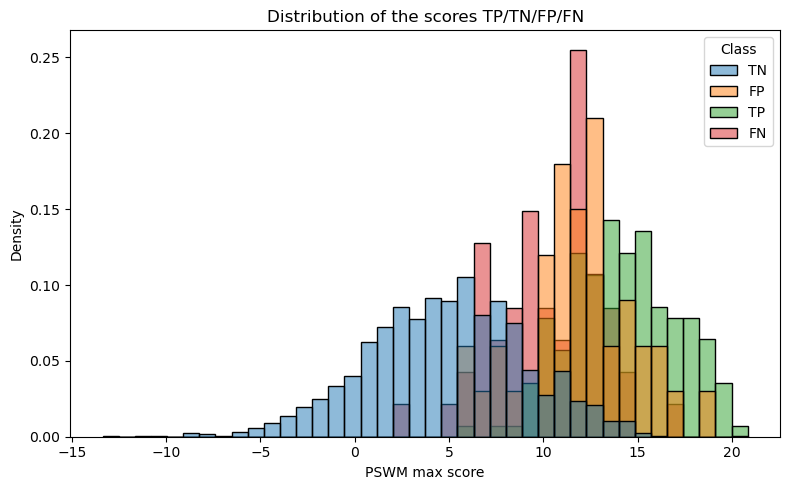

In [78]:
# Lista delle sequenze del benchmark
seqs_bench = df["Sequence"].tolist()

# Calcolo dello score PSWM massimo per ogni sequenza
pswm_scores_bench = highest_pswm_scores_aligned(
    pswm,
    seqs_bench,
    window_size=pswm_len    
)


df["pswm_score"] = pswm_scores_bench

scores_TP = df[df["results"] == "TP"]["pswm_score"]
scores_TN = df[df["results"] == "TN"]["pswm_score"]
scores_FP = df[df["results"] == "FP"]["pswm_score"]
scores_FN = df[df["results"] == "FN"]["pswm_score"]

df_pswm_plot = df[["pswm_score", "results"]].copy()
df_pswm_plot.rename(columns={"results": "Class"},inplace=True)
                    
plt.figure(figsize=(8,5))
sns.histplot(
    data=df_pswm_plot,
    x="pswm_score",
    hue="Class",          # TP / TN / FP / FN
    stat="density",
    common_norm=False,
    bins=40,
    multiple="layer",     
    alpha=0.5
)

plt.title("Distribution of the scores TP/TN/FP/FN")
plt.xlabel("PSWM max score")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("pswm_scores_hist_TP_TN_FP_FN.png", dpi=300)
plt.show()

Best PSWM threshold = 10.925723505343974
Best validation MCC = 0.5869039968568863


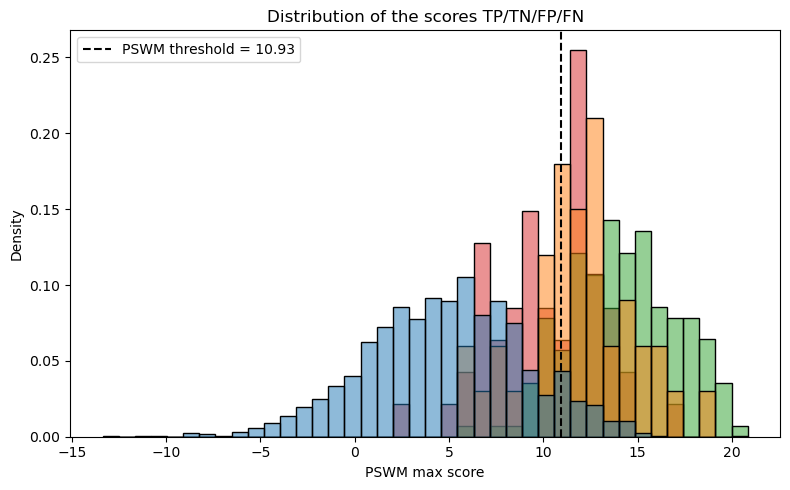

In [79]:
# score PSWM sul validation set
pswm_scores_val = highest_pswm_scores_aligned(
    pswm,
    val_seqs,
    window_size=pswm_len
).ravel()


from sklearn.metrics import matthews_corrcoef
import numpy as np

best_thr = None
best_mcc = -1.0

min_s, max_s = pswm_scores_val.min(), pswm_scores_val.max()

for t in np.linspace(min_s, max_s, 400):
    y_pred = (pswm_scores_val > t).astype(int)
    mcc = matthews_corrcoef(val_labels, y_pred)
    if mcc > best_mcc:
        best_mcc = mcc
        best_thr = t

print("Best PSWM threshold =", best_thr)
print("Best validation MCC =",best_mcc)
      

plt.figure(figsize=(8,5))
sns.histplot(
    data=df_pswm_plot,
    x="pswm_score",
    hue="Class",
    stat="density",
    common_norm=False,
    bins=40,
    multiple="layer",
    alpha=0.5
)

plt.axvline(best_thr, color="black", linestyle="--", label=f"PSWM threshold = {best_thr:.2f}")

plt.title("Distribution of the scores TP/TN/FP/FN")
plt.xlabel("PSWM max score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("pswm_scores_hist_TP_TN_FP_FN_with_thr.png", dpi=300)
plt.show()

il grafico sopra deriva da labeling (TP,FN...) che derivano dall'SVM, dunque il fatto che i FN siano oltre il threshold del Von Hejine potrebbe essere normale. Infatti l'SVM tratta tutte le feature allo stesso modo e il fatto che alcune sequenze sono targettate FN può derivare da altre features!